# LLM-as-a-Judge Debiasing Experiments

This notebook runs the experiments for evaluating whether inference-time debiasing strategies improve small open-weight LLM judges.

Experiments take some time to run, as tested on G4 GPU runtime environment. Since MT-Bench is multi-turn, models are ran separately on the dataset to reduce compute time.


Strategies tested are S0a (minimal baseline), S0b (impartiality instructions), S1 (order-swap), S5 (Rubric based evaluation), S6 (pointwise scoring), and S7 (a forced choice swap diagnostic metric for position bias). S2 (chain of thought), S3 (majority voting), and S4 (order-swap + chain of thought) were not used due to compute constraints.

S5, S6, and S7 are renamed to be S2, S3, and S4 respectively in order to establish consistency.

In [ ]:
from pathlib import Path
import json, re, math, csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
!pip install torch transformers accelerate datasets scikit-learn matplotlib


In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1" "transformers>=4.43" "accelerate>=0.27" "datasets>=2.18" "scikit-learn>=1.3" "matplotlib>=3.8"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 45.3 MB/s eta 0:00:00


In [ ]:
!python run_experiment.py --dataset mt_bench --mt_bench_turns both --models qwen --strategies S0a S0b S1 S5 S6 S7 --load_in_4bit


Dataset: mt_bench, turns=both (all)
README.md: 2.00kB [00:00, 1.46MB/s]
data/gpt4_pair-00000-of-00001-c0b431264a(…): 100% 650k/650k [00:01<00:00, 443kB/s] 
data/human-00000-of-00001-25f49108187592(…): 100% 739k/739k [00:00<00:00, 3.62MB/s]
Generating gpt4_pair split: 100% 2400/2400 [00:00<00:00, 273601.04 examples/s]
Generating human split: 100% 3355/3355 [00:00<00:00, 404248.49 examples/s]
Loaded 1698 pairs

Pre-computing token lengths with Qwen2.5-7B-Instruct...
Loading Qwen2.5-7B-Instruct (Qwen/Qwen2.5-7B-Instruct)...
config.json: 100% 663/663 [00:00<00:00, 8.33MB/s]
tokenizer_config.json: 7.30kB [00:00, 37.2MB/s]
vocab.json: 2.78MB [00:00, 37.8MB/s]
merges.txt: 1.67MB [00:00, 45.6MB/s]
tokenizer.json: 7.03MB [00:00, 19.9MB/s]
model.safetensors.index.json: 27.8kB [00:00, 169MB/s]
Fetching 4 files: 100% 4/4 [00:36<00:00,  9.01s/it]
Download complete: 100% 15.2G/15.2G [00:36<00:00, 418MB/s]
Loading weights: 100% 339/339 [00:01<00:00, 234.85it/s]
generation_config.json: 100% 243/243 [0

In [ ]:
!python run_experiment.py --dataset mt_bench --mt_bench_turns both --models mistral --strategies S0a S0b S1 S5 S6 S7 --load_in_4bit


Dataset: mt_bench, turns=both (all)
Loaded 1698 pairs

Pre-computing token lengths with Mistral-7B-Instruct-v0.3...
Loading Mistral-7B-Instruct-v0.3 (mistralai/Mistral-7B-Instruct-v0.3)...
config.json: 100% 601/601 [00:00<00:00, 6.70MB/s]
tokenizer_config.json: 141kB [00:00, 59.9MB/s]
tokenizer.model: 100% 587k/587k [00:00<00:00, 726kB/s] 
tokenizer.json: 1.96MB [00:00, 15.6MB/s]
special_tokens_map.json: 100% 414/414 [00:00<00:00, 5.77MB/s]
model.safetensors.index.json: 23.9kB [00:00, 111MB/s]
Fetching 3 files: 100% 3/3 [00:34<00:00, 11.38s/it]
Download complete: 100% 14.5G/14.5G [00:34<00:00, 425MB/s]
Loading weights: 100% 291/291 [00:01<00:00, 250.15it/s]
generation_config.json: 100% 116/116 [00:00<00:00, 1.53MB/s]
Loaded: Mistral-7B-Instruct-v0.3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Judge: Mistral-7B-Instruct-v0.3  |  mt_bench  (1698 pairs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── S0a: Minimal ──
  S0a: 25/1698 (1%)
  S0a: 50/1698 (

In [ ]:
!python run_experiment.py --dataset mt_bench --mt_bench_turns both --models olmo --strategies S0a S0b S1 S5 S6 S7 --load_in_4bit


Dataset: mt_bench, turns=both (all)
Loaded 1698 pairs

Pre-computing token lengths with OLMo-2-7B-Instruct...
Loading OLMo-2-7B-Instruct (allenai/OLMo-2-1124-7B-Instruct)...
config.json: 100% 679/679 [00:00<00:00, 7.80MB/s]
tokenizer_config.json: 4.88kB [00:00, 24.1MB/s]
vocab.json: 1.61MB [00:00, 7.61MB/s]
merges.txt: 917kB [00:00, 9.12MB/s]
special_tokens_map.json: 100% 581/581 [00:00<00:00, 8.32MB/s]
tokenizer.json: 7.14MB [00:00, 20.1MB/s]
model.safetensors.index.json: 29.6kB [00:00, 136MB/s]
Fetching 3 files: 100% 3/3 [00:36<00:00, 12.01s/it]
Download complete: 100% 14.6G/14.6G [00:36<00:00, 405MB/s]
Loading weights: 100% 355/355 [00:01<00:00, 301.20it/s]
generation_config.json: 100% 126/126 [00:00<00:00, 1.63MB/s]
Loaded: OLMo-2-7B-Instruct

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Judge: OLMo-2-7B-Instruct  |  mt_bench  (1698 pairs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── S0a: Minimal ──
  S0a: 25/1698 (1%)
  S0a: 50/1698 (3%)
  S0a

In [ ]:
!python run_experiment.py --dataset chatbot_arena --models qwen mistral olmo --strategies S0a S0b S1 S5 S6 S7 --n_pairs 2000 --load_in_4bit


Dataset: chatbot_arena (n=2000)
  ChatBot Arena filter (33000 rows): non_english=3794, ties=8536, same_model=0, moderation=0, short_conv=0, empty_text=28, kept=20642
Loaded 2000 pairs

Pre-computing token lengths with Qwen2.5-7B-Instruct...
Loading Qwen2.5-7B-Instruct (Qwen/Qwen2.5-7B-Instruct)...
Loading weights: 100% 339/339 [00:01<00:00, 283.95it/s]
Loaded: Qwen2.5-7B-Instruct

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Judge: Qwen2.5-7B-Instruct  |  chatbot_arena  (2000 pairs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── S0a: Minimal ──
  S0a: 25/2000 (1%)
  S0a: 50/2000 (2%)
  S0a: 75/2000 (4%)
  S0a: 100/2000 (5%)
  S0a: 125/2000 (6%)
  S0a: 150/2000 (8%)
  S0a: 175/2000 (9%)
  S0a: 200/2000 (10%)
  S0a: 225/2000 (11%)
  S0a: 250/2000 (12%)
  S0a: 275/2000 (14%)
  S0a: 300/2000 (15%)
  S0a: 325/2000 (16%)
  S0a: 350/2000 (18%)
  S0a: 375/2000 (19%)
  S0a: 400/2000 (20%)
  S0a: 425/2000 (21%)
  S0a: 450/2000 (22%)
  S0a: 475/2000 (24%)
  S0a

In [ ]:
!python run_experiment.py --dataset mt_bench --mt_bench_turns both --models qwen14b --strategies S0a S0b S1 S5 S6 S7 --load_in_4bit


Dataset: mt_bench, turns=both (all)
Loaded 1698 pairs

Pre-computing token lengths with Qwen2.5-14B-Instruct...
Loading Qwen2.5-14B-Instruct (Qwen/Qwen2.5-14B-Instruct)...
config.json: 100% 663/663 [00:00<00:00, 7.42MB/s]
tokenizer_config.json: 7.30kB [00:00, 36.6MB/s]
vocab.json: 2.78MB [00:00, 8.92MB/s]
merges.txt: 1.67MB [00:00, 7.37MB/s]
tokenizer.json: 7.03MB [00:00, 14.7MB/s]
model.safetensors.index.json: 47.5kB [00:00, 21.0MB/s]
Fetching 8 files: 100% 8/8 [01:18<00:00,  9.76s/it]
Download complete: 100% 29.5G/29.5G [01:18<00:00, 822MB/s]                
Loading weights:   0% 0/579 [00:00<?, ?it/s]
Loading weights:   0% 1/579 [00:00<01:03,  9.07it/s]
Loading weights:   0% 2/579 [00:00<01:03,  9.12it/s]
Loading weights:   4% 24/579 [00:00<00:05, 99.50it/s]
Loading weights:   9% 53/579 [00:00<00:03, 165.56it/s]
Loading weights:  14% 82/579 [00:00<00:02, 205.91it/s]
Loading weights:  19% 112/579 [00:00<00:01, 234.07it/s]
Loading weights:  24% 137/579 [00:00<00:01, 236.66it/s]
Loadin

In [ ]:
!python run_experiment.py --dataset chatbot_arena --models qwen14b --strategies S0a S0b S1 S5 S6 S7 --n_pairs 2000 --load_in_4bit


Dataset: chatbot_arena (n=2000)
  ChatBot Arena filter (33000 rows): non_english=3794, ties=8536, same_model=0, moderation=0, short_conv=0, empty_text=28, kept=20642
Loaded 2000 pairs

Pre-computing token lengths with Qwen2.5-14B-Instruct...
Loading Qwen2.5-14B-Instruct (Qwen/Qwen2.5-14B-Instruct)...
Loading weights: 100% 579/579 [00:02<00:00, 250.92it/s]
Loaded: Qwen2.5-14B-Instruct

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Judge: Qwen2.5-14B-Instruct  |  chatbot_arena  (2000 pairs)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── S0a: Minimal ──
  S0a: 25/2000 (1%)
  S0a: 50/2000 (2%)
  S0a: 75/2000 (4%)
  S0a: 100/2000 (5%)
  S0a: 125/2000 (6%)
  S0a: 150/2000 (8%)
  S0a: 175/2000 (9%)
  S0a: 200/2000 (10%)
  S0a: 225/2000 (11%)
  S0a: 250/2000 (12%)
  S0a: 275/2000 (14%)
  S0a: 300/2000 (15%)
  S0a: 325/2000 (16%)
  S0a: 350/2000 (18%)
  S0a: 375/2000 (19%)
  S0a: 400/2000 (20%)
  S0a: 425/2000 (21%)
  S0a: 450/2000 (22%)
  S0a: 475/2000 (24%)


In [ ]:
!zip -r results.zip results

updating: results/ (stored 0%)
updating: results/chatbot_arena/ (stored 0%)
updating: results/chatbot_arena/checkpoints/ (stored 0%)
updating: results/chatbot_arena/checkpoints/mistral/ (stored 0%)
updating: results/chatbot_arena/checkpoints/mistral/S7.json (deflated 84%)
updating: results/chatbot_arena/checkpoints/mistral/S6.json (deflated 85%)
updating: results/chatbot_arena/checkpoints/mistral/S0b.json (deflated 82%)
updating: results/chatbot_arena/checkpoints/mistral/S0a.json (deflated 82%)
updating: results/chatbot_arena/checkpoints/mistral/S5.json (deflated 86%)
updating: results/chatbot_arena/checkpoints/mistral/S1.json (deflated 84%)
updating: results/chatbot_arena/checkpoints/qwen/ (stored 0%)
updating: results/chatbot_arena/checkpoints/qwen/S7.json (deflated 85%)
updating: results/chatbot_arena/checkpoints/qwen/S6.json (deflated 85%)
updating: results/chatbot_arena/checkpoints/qwen/S0b.json (deflated 82%)
updating: results/chatbot_arena/checkpoints/qwen/S0a.json (deflated 82%

In [ ]:
!unzip results.zip

Archive:  results.zip
   creating: results/
  inflating: __MACOSX/._results      
   creating: results/chatbot_arena/
  inflating: __MACOSX/results/._chatbot_arena  
   creating: results/mt_bench/
  inflating: __MACOSX/results/._mt_bench  
  inflating: results/chatbot_arena/full_results.json  
  inflating: __MACOSX/results/chatbot_arena/._full_results.json  
   creating: results/chatbot_arena/checkpoints/
  inflating: __MACOSX/results/chatbot_arena/._checkpoints  
  inflating: results/mt_bench/full_results.json  
  inflating: __MACOSX/results/mt_bench/._full_results.json  
   creating: results/mt_bench/checkpoints/
  inflating: __MACOSX/results/mt_bench/._checkpoints  
   creating: results/chatbot_arena/checkpoints/olmo/
  inflating: __MACOSX/results/chatbot_arena/checkpoints/._olmo  
   creating: results/chatbot_arena/checkpoints/qwen/
  inflating: __MACOSX/results/chatbot_arena/checkpoints/._qwen  
   creating: results/chatbot_arena/checkpoints/qwen14b/
  inflating: __MACOSX/results/

# Exploratory Data Analysis

This section reloads the saved checkpoint files and calculates metrics from judge verdicts. Each checkpoint corresponds to one dataset, model, and strategy combination. The goal is to compare strategies not only by human-label agreement, but also by whether they reduce bias or simply increase the number of ties.

In [ ]:
BASE_DIR = Path("/content/")
RESULTS_DIR = BASE_DIR / "results"
OUT_DIR = BASE_DIR / "report_assets"
OUT_DIR.mkdir(exist_ok=True)

DATASETS = ["mt_bench", "chatbot_arena"]
MODELS = ["qwen", "mistral", "olmo", "qwen14b"]
STRATEGIES = ["S0a", "S0b", "S1", "S5", "S6", "S7"]
STRATEGY_DISPLAY = {
    "S0a": "S0a",
    "S0b": "S0b",
    "S1": "S1",
    "S5": "S2",
    "S6": "S3",
    "S7": "S4",
}
DISPLAY_STRATEGIES = [STRATEGY_DISPLAY[s] for s in STRATEGIES]

DATASET_LABELS = {
    "mt_bench": "MT-Bench",
    "chatbot_arena": "Chatbot Arena",
}

MODEL_LABELS = {
    "qwen": "Qwen-7B",
    "mistral": "Mistral-7B",
    "olmo": "OLMo-7B",
    "qwen14b": "Qwen-14B",
}


In [ ]:
def load_checkpoint(dataset, model, strategy):
    path = RESULTS_DIR / dataset / "checkpoints" / model / f"{strategy}.json"
    with open(path) as f:
        return json.load(f)

checkpoints = {}

for dataset in DATASETS:
    for model in MODELS:
        for strategy in STRATEGIES:
            checkpoints[(dataset, model, strategy)] = load_checkpoint(dataset, model, strategy)

print("Loaded", len(checkpoints), "checkpoint files")


Loaded 48 checkpoint files


In [ ]:
def compute_metrics(dataset, model, strategy, ckpt):
    verdicts = ckpt["verdicts"]
    traces = ckpt["row_traces"]

    human = [t["human_label"] for t in traces]
    len_a = [t["len_a"] for t in traces]
    len_b = [t["len_b"] for t in traces]
    n = len(verdicts)

    strict = sum(v == h for v, h in zip(verdicts, human)) / n
    tie_rate = sum(v == "tie" for v in verdicts) / n

    non_tie = [(v, h) for v, h in zip(verdicts, human) if v != "tie"]
    lenient = (sum(v == h for v, h in non_tie) / len(non_tie) if non_tie else None)

    human_a_rate = sum(h == "A" for h in human) / n
    judge_a_rate = sum(v == "A" for v in verdicts) / n

    judge_longer, human_longer = [], []

    for v, h, la, lb in zip(verdicts, human, len_a, len_b):
        if la == lb:
            continue

        longer = "A" if la > lb else "B"
        judge_longer.append(1 if v == longer else 0)
        human_longer.append(1 if h == longer else 0)

    judge_longer_rate = sum(judge_longer) / len(judge_longer)
    human_longer_rate = sum(human_longer) / len(human_longer)
    vbi = judge_longer_rate - human_longer_rate

    return {
        "dataset": dataset,
        "dataset_label": DATASET_LABELS[dataset],
        "model": model,
        "model_label": MODEL_LABELS[model],
        "strategy_raw": strategy,
        "strategy_renamed": STRATEGY_DISPLAY[strategy],
        "n": n,
        "strict_agreement": strict,
        "lenient_agreement": lenient,
        "tie_rate": tie_rate,
        "vbi": vbi,
        "abs_vbi": abs(vbi),
        "human_a_rate": human_a_rate,
        "judge_a_rate": judge_a_rate,
        "a_rate_deviation": judge_a_rate - human_a_rate,
        "abs_a_rate_deviation": abs(judge_a_rate - human_a_rate),
    }

rows = []

for dataset in DATASETS:
    for model in MODELS:
        for strategy in STRATEGIES:
            rows.append(compute_metrics(dataset, model, strategy, checkpoints[(dataset, model, strategy)]))

per_setting = pd.DataFrame(rows)


In [ ]:
per_setting

,dataset,dataset_label,model,model_label,strategy_raw,strategy_renamed,n,strict_agreement,lenient_agreement,tie_rate,vbi,abs_vbi,human_a_rate,judge_a_rate,a_rate_deviation,abs_a_rate_deviation
0,mt_bench,MT-Bench,qwen,Qwen-7B,S0a,S0a,1698,0.766784,0.767689,0.001178,-0.029167,0.029167,0.499411,0.595406,0.095995,0.095995
1,mt_bench,MT-Bench,qwen,Qwen-7B,S0b,S0b,1698,0.612485,0.804331,0.238516,-0.151786,0.151786,0.499411,0.388104,-0.111307,0.111307
2,mt_bench,MT-Bench,qwen,Qwen-7B,S1,S1,1698,0.624264,0.844622,0.260895,-0.131548,0.131548,0.499411,0.369258,-0.130153,0.130153
3,mt_bench,MT-Bench,qwen,Qwen-7B,S5,S2,1698,0.762662,0.778713,0.020612,-0.013690,0.013690,0.499411,0.543581,0.044170,0.044170
4,mt_bench,MT-Bench,qwen,Qwen-7B,S6,S3,1698,0.574205,0.844156,0.319788,-0.214286,0.214286,0.499411,0.332155,-0.167256,0.167256
5,mt_bench,MT-Bench,qwen,Qwen-7B,S7,S4,1698,0.674323,0.845643,0.202591,-0.105952,0.105952,0.499411,0.406360,-0.093051,0.093051
6,mt_bench,MT-Bench,mistral,Mistral-7B,S0a,S0a,1698,0.689635,0.695781,0.008834,-0.043504,0.043504,0.499411,0.709069,0.209658,0.209658
7,mt_bench,MT-Bench,mistral,Mistral-7B,S0b,S0b,1698,0.627208,0.702044,0.106596,-0.084625,0.084625,0.499411,0.667845,0.168433,0.168433
8,mt_bench,MT-Bench,mistral,Mistral-7B,S1,S1,1698,0.489988,0.861284,0.431095,-0.219905,0.219905,0.499411,0.276796,-0.222615,0.222615
9,mt_bench,MT-Bench,mistral,Mistral-7B,S5,S2,1698,0.670200,0.686783,0.024146,-0.056019,0.056019,0.499411,0.746761,0.247350,0.247350


In [ ]:
maint = (per_setting
    .groupby("strategy_renamed", sort=False)
    .agg(strict_agreement=("strict_agreement", "mean"),
        lenient_agreement=("lenient_agreement", "mean"),
        tie_rate=("tie_rate", "mean"),
        abs_vbi=("abs_vbi", "mean"),
        abs_a_rate_deviation=("abs_a_rate_deviation", "mean"),).reset_index())

maint = maint.set_index("strategy_renamed").loc[DISPLAY_STRATEGIES].reset_index()
maint.round(3)


,strategy_renamed,strict_agreement,lenient_agreement,tie_rate,abs_vbi,abs_a_rate_deviation
0,S0a,0.719,0.724,0.008,0.028,0.089
1,S0b,0.627,0.743,0.156,0.085,0.092
2,S1,0.541,0.817,0.340,0.168,0.174
3,S2,0.706,0.720,0.019,0.028,0.105
4,S3,0.463,0.782,0.415,0.273,0.217
5,S4,0.537,0.821,0.344,0.184,0.175


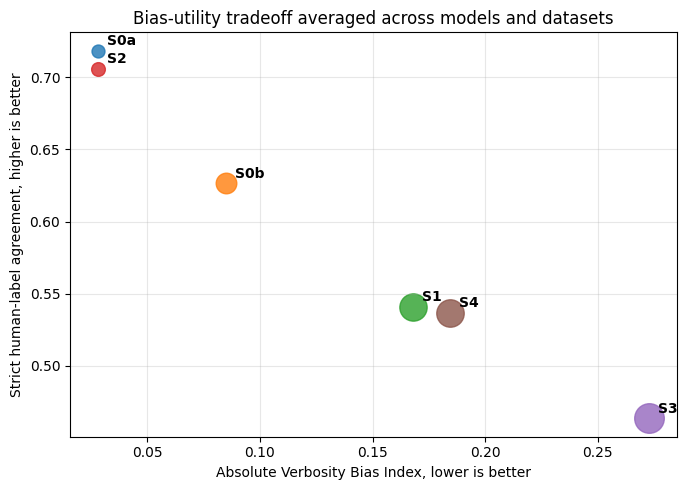

In [ ]:
plt.figure(figsize=(7, 5))

for _, row in maint.iterrows():
    size = 80 + 900 * row["tie_rate"]
    plt.scatter(row["abs_vbi"], row["strict_agreement"], s=size, alpha=0.8)
    plt.text(row["abs_vbi"] + 0.004, row["strict_agreement"] + 0.004, row["strategy_renamed"], weight="bold")

plt.xlabel("Absolute Verbosity Bias Index, lower is better")
plt.ylabel("Strict human-label agreement, higher is better")
plt.title("Bias-utility tradeoff averaged across models and datasets")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_bias_utility_tradeoff.png", dpi=200)
plt.show()


This chart compares strict human-label agreement against absolute verbosity bias. Each point is a strategy, and larger bubbles indicate higher tie rates. The ideal strategy would appear near the upper-left corner indicating high agreement, low verbosity bias, and a smaller bubble.


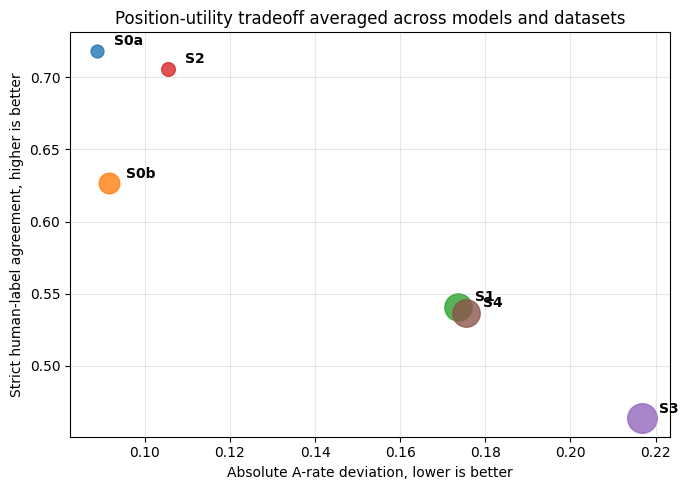

In [ ]:
plt.figure(figsize=(7, 5))

for _, row in maint.iterrows():
    size = 80 + 900 * row["tie_rate"]
    plt.scatter(row["abs_a_rate_deviation"], row["strict_agreement"], s=size, alpha=0.8)
    plt.text(
        row["abs_a_rate_deviation"] + 0.004,
        row["strict_agreement"] + 0.004,
        row["strategy_renamed"],
        weight="bold"
    )

plt.xlabel("Absolute A-rate deviation, lower is better")
plt.ylabel("Strict human-label agreement, higher is better")
plt.title("Position-utility tradeoff averaged across models and datasets")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_position_utility_tradeoff.png", dpi=200)
plt.show()


This chart compares strict agreement against absolute A-rate deviation, which is used as a proxy for position preference. Strategies farther left have lower A/B selection imbalance, while strategies higher on the plot better match human labels. Bubble size indicates tie rates. Minimal baseline performs the best, while pointwise scoring performs the worst.


In [ ]:
target_bias = {
    "S0b": "General position + verbosity",
    "S1": "Position",
    "S2": "Verbosity / style",
    "S3": "Position + verbosity",
    "S4": "Position diagnostic",
}

rows = []

for strategy in ["S0b", "S1", "S2", "S3", "S4"]:
    deltas = []

    for dataset in per_setting["dataset"].unique():
        for model in per_setting["model"].unique():
            base = per_setting[
                (per_setting["dataset"] == dataset)
                & (per_setting["model"] == model)
                & (per_setting["strategy_renamed"] == "S0a")
            ]

            after = per_setting[
                (per_setting["dataset"] == dataset)
                & (per_setting["model"] == model)
                & (per_setting["strategy_renamed"] == strategy)
            ]

            if base.empty or after.empty:
                continue

            base = base.iloc[0]
            after = after.iloc[0]

            deltas.append({
                "delta_strict": after["strict_agreement"] - base["strict_agreement"],
                "delta_lenient": after["lenient_agreement"] - base["lenient_agreement"],
                "delta_tie": after["tie_rate"] - base["tie_rate"],
                "delta_abs_vbi": after["abs_vbi"] - base["abs_vbi"],
                "delta_abs_a_rate_dev": after["abs_a_rate_deviation"] - base["abs_a_rate_deviation"],
                "vbi_reduced": after["abs_vbi"] < base["abs_vbi"],
                "a_rate_reduced": after["abs_a_rate_deviation"] < base["abs_a_rate_deviation"],
            })

    d = pd.DataFrame(deltas)

    rows.append({
        "Strategy": strategy,
        "Target Bias": target_bias[strategy],
        "Δ Strict": d["delta_strict"].mean(),
        "Δ Lenient": d["delta_lenient"].mean(),
        "Δ Tie": d["delta_tie"].mean(),
        "Δ |VBI|": d["delta_abs_vbi"].mean(),
        "Δ |A-rate dev.|": d["delta_abs_a_rate_dev"].mean(),
        "VBI Reduced": f"{d['vbi_reduced'].sum()}/{len(d)}",
        "A-rate Dev. Reduced": f"{d['a_rate_reduced'].sum()}/{len(d)}",
    })

delta_table = pd.DataFrame(rows)
delta_table.round(3)


,Strategy,Target Bias,Δ Strict,Δ Lenient,Δ Tie,Δ |VBI|,Δ |A-rate dev.|,VBI Reduced,A-rate Dev. Reduced
0,S0b,General position + verbosity,-0.092,0.019,0.148,0.057,0.003,3/8,3/8
1,S1,Position,-0.178,0.093,0.332,0.140,0.085,0/8,1/8
2,S2,Verbosity / style,-0.013,-0.004,0.012,0.000,0.017,4/8,2/8
3,S3,Position + verbosity,-0.255,0.058,0.408,0.245,0.128,0/8,1/8
4,S4,Position diagnostic,-0.182,0.097,0.337,0.156,0.087,0/8,1/8


In [ ]:
tie_rows = []

for strategy in ["S0b", "S1", "S5", "S6", "S7"]:
    induced_ties = 0
    correct_s0a_to_tie = 0

    for dataset in DATASETS:
        for model in MODELS:
            base = checkpoints[(dataset, model, "S0a")]
            other = checkpoints[(dataset, model, strategy)]

            human = [t["human_label"] for t in base["row_traces"]]

            for base_v, other_v, h in zip(base["verdicts"], other["verdicts"], human):
                if other_v == "tie" and base_v != "tie":
                    induced_ties += 1
                    correct_s0a_to_tie += int(base_v == h)

    tie_rows.append({
        "strategy_raw": strategy,
        "strategy": STRATEGY_DISPLAY[strategy],
        "induced_ties": induced_ties,
        "correct_s0a_converted_to_tie_count": correct_s0a_to_tie,
        "correct_s0a_converted_to_tie": correct_s0a_to_tie / induced_ties,
    })

tie_mechanism = pd.DataFrame(tie_rows)
tie_mechanism.round(3)


,strategy_raw,strategy,induced_ties,correct_s0a_converted_to_tie_count,correct_s0a_converted_to_tie
0,S0b,S0b,2316,1462,0.631
1,S1,S1,4975,2956,0.594
2,S5,S2,256,149,0.582
3,S6,S3,6056,3946,0.652
4,S7,S4,5042,2993,0.594


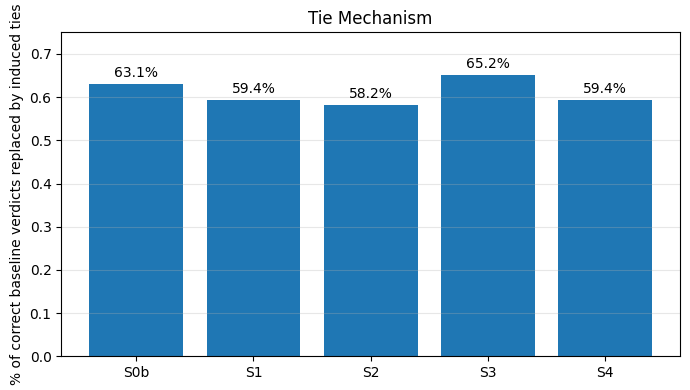

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    tie_mechanism["strategy"],
    tie_mechanism["correct_s0a_converted_to_tie"],
)

for i, row in tie_mechanism.iterrows():
    plt.text(
        i,
        row["correct_s0a_converted_to_tie"] + 0.015,
        f"{row['correct_s0a_converted_to_tie'] * 100:.1f}%",
        ha="center",
    )

plt.ylim(0, 0.75)
plt.ylabel("% of correct baseline verdicts replaced by induced ties")
plt.title("Tie Mechanism")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_tie_mechanism.png", dpi=200)
plt.show()



This chart shows the percentage of induced ties that replaced correct S0a baseline verdicts. Higher values suggest that the strategy is not only avoiding uncertain cases, but also turning many previously correct decisions into ties.


In [ ]:
qwen_scale = per_setting[
    per_setting["model"].isin(["qwen", "qwen14b"])
].copy()

qwen_scale["model_label"] = qwen_scale["model"].map({
    "qwen": "Qwen-7B",
    "qwen14b": "Qwen-14B",
})

qwen_avg = (
    qwen_scale
    .groupby(["strategy_renamed", "model_label"], sort=False)
    .agg(
        strict_agreement=("strict_agreement", "mean"),
        tie_rate=("tie_rate", "mean"),
        abs_vbi=("abs_vbi", "mean"),
        abs_a_rate_deviation=("abs_a_rate_deviation", "mean"),
    )
    .reset_index()
)

qwen_avg["strategy"] = pd.Categorical(qwen_avg["strategy_renamed"], DISPLAY_STRATEGIES, ordered=True)
qwen_avg = qwen_avg.sort_values(["strategy", "model_label"])

qwen_avg.round(3)


,strategy_renamed,model_label,strict_agreement,tie_rate,abs_vbi,abs_a_rate_deviation,strategy
6,S0a,Qwen-14B,0.787,0.005,0.019,0.013,S0a
0,S0a,Qwen-7B,0.740,0.002,0.026,0.101,S0a
7,S0b,Qwen-14B,0.745,0.058,0.026,0.038,S0b
1,S0b,Qwen-7B,0.526,0.328,0.199,0.175,S0b
8,S1,Qwen-14B,0.682,0.181,0.085,0.099,S1
2,S1,Qwen-7B,0.564,0.312,0.166,0.158,S1
9,S2,Qwen-14B,0.784,0.009,0.022,0.034,S2
3,S2,Qwen-7B,0.728,0.030,0.027,0.028,S2
10,S3,Qwen-14B,0.619,0.269,0.154,0.148,S3
4,S3,Qwen-7B,0.537,0.354,0.219,0.191,S3


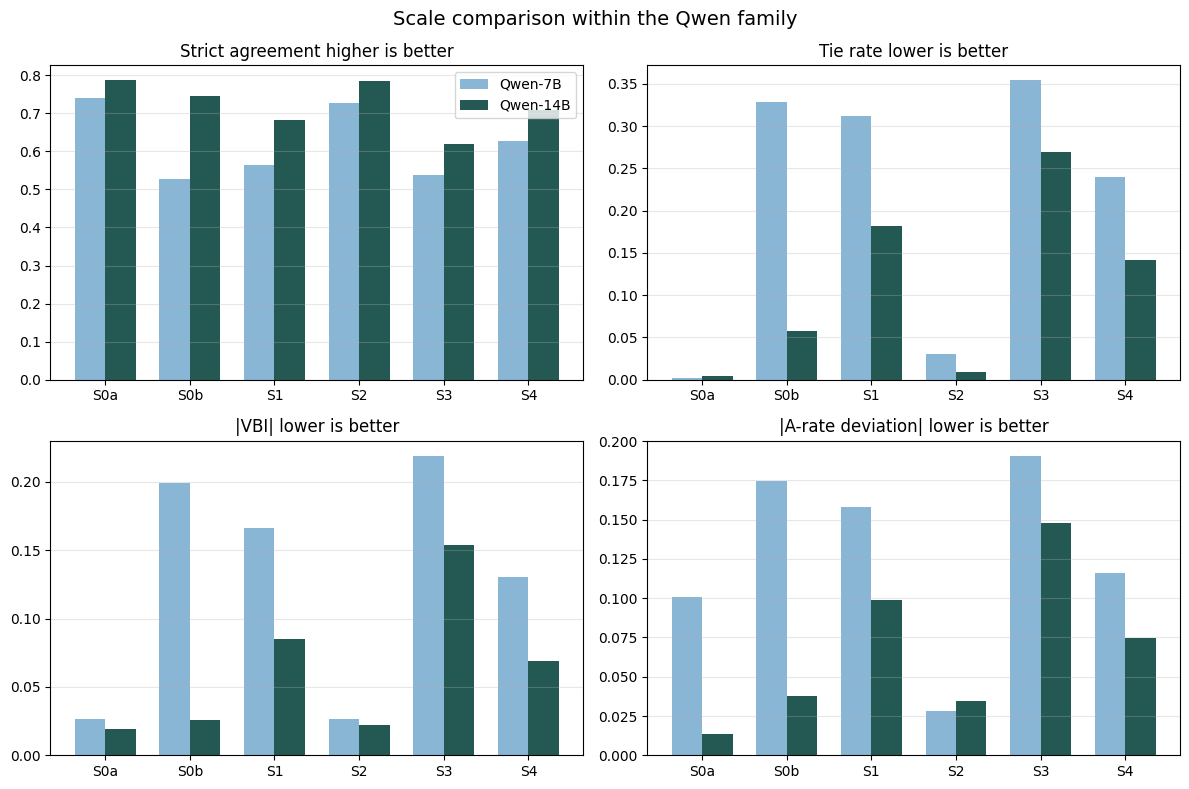

In [ ]:
metrics = [
    ("strict_agreement", "Strict agreement", "higher is better"),
    ("tie_rate", "Tie rate", "lower is better"),
    ("abs_vbi", "|VBI|", "lower is better"),
    ("abs_a_rate_deviation", "|A-rate deviation|", "lower is better"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

x = range(len(DISPLAY_STRATEGIES))
width = 0.36

colors = {
    "Qwen-7B": "#8AB6D6",
    "Qwen-14B": "#245953",
}

for ax, (metric, title, subtitle) in zip(axes, metrics):
    vals_7b = (
        qwen_avg[qwen_avg["model_label"] == "Qwen-7B"]
        .set_index("strategy")
        .loc[DISPLAY_STRATEGIES, metric]
    )

    vals_14b = (
        qwen_avg[qwen_avg["model_label"] == "Qwen-14B"]
        .set_index("strategy")
        .loc[DISPLAY_STRATEGIES, metric]
    )

    ax.bar([i - width/2 for i in x], vals_7b, width, label="Qwen-7B", color=colors["Qwen-7B"])
    ax.bar([i + width/2 for i in x], vals_14b, width, label="Qwen-14B", color=colors["Qwen-14B"])

    ax.set_title(f"{title} {subtitle}")
    ax.set_xticks(list(x))
    ax.set_xticklabels(DISPLAY_STRATEGIES)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend()

plt.suptitle("Scale comparison within the Qwen family", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_qwen_7b_vs_14b_all_metrics.png", dpi=220)
plt.show()


This chart compares Qwen-7B and Qwen-14B across strict agreement, tie rate, absolute verbosity bias, and absolute A-rate deviation. It helps show whether the larger model handles debiasing prompts more reliably than the smaller model.
